# Generative AI for Data Augmentation

CyberEye Solutions, an emerging leader in cybersecurity for critical infrastructures, is facing a growing challenge in protecting power plants against advanced cyber threats. Currently, the power plant surveillance system uses image recognition technologies to identify and promptly respond to potentially dangerous situations. However, the ability to accurately and quickly recognize critical objects and behaviors in images is limited by the training datasets currently available, which do not fully represent the variability and complexity of real-world situations.

At present, existing models based on limited datasets fail to detect anomalies or potential threats in images with the required level of accuracy, compromising the company’s ability to respond to and mitigate emergency situations. Improving the ability to promptly identify critical objects and behaviors in images is essential to ensure operational continuity and the security of the critical infrastructures managed by CyberEye Solutions.

**Benefits of the Solution**

**1. Improved Security of Critical Infrastructures:**

Expanding the dataset using advanced Data Augmentation techniques will improve the accuracy of the image recognition system. A more precise and reliable model will be able to detect suspicious behaviors or potential threats in power plant images more quickly and accurately, thereby enhancing the security of critical infrastructures and reducing the risk of incidents or sabotage.

**2. Operational Efficiency and Reduced Response Time:**

By automating the process of generating new data through the creation of varied images and texts, CyberEye Solutions will optimize operational efficiency. This will allow the company to focus human resources on threat analysis and mitigation activities, reducing response times to critical events and improving emergency management capabilities.

**3. Technological Innovation in the Security Sector:**

By leveraging advanced deep learning and data generation techniques, CyberEye Solutions will foster innovation in the field of cybersecurity for critical infrastructures. The implementation of more sophisticated image recognition models will not only enhance the security of power plants, but also demonstrate the company’s commitment to adopting cutting-edge technologies to address emerging challenges in the cybersecurity sector.

**Project Details**

- **Dataset Acquisition:**

Use the OxfordIIITPet dataset from PyTorch as the foundation for the project aimed at improving the image recognition system for critical infrastructures.

- **Image Captioning and Data Generation:**

Apply image captioning to create initial descriptions of the images. Subsequently, use a text generation model to produce variations or analogous descriptions. Finally, employ an image generation model to create new images from the original captions or generated texts, thereby enriching the dataset with synthetic data.

**Model Training:**

Train an image recognition model using the expanded dataset, evaluating the quality of the generated data and comparing model performance on the reduced dataset versus the augmented dataset.

**Performance Evaluation:**

Measure accuracy, precision, recall, and other performance metrics to compare the model trained on both datasets. Discuss performance differences and the effectiveness of Data Augmentation techniques in improving model accuracy in real-world critical infrastructure security contexts.

**Conclusions**

CyberEye Solutions is committed to strengthening the security of critical infrastructures through the implementation of advanced image recognition solutions. By adopting innovative approaches and cutting-edge technologies, the company aims not only to improve the effectiveness of its cybersecurity systems, but also to set new industry standards for protecting critical infrastructures against increasingly sophisticated cyber threats.

**Delivery Method**

Public link to a Google Colab notebook

# Environment Setup & Dataset Preparation

This section initializes the Colab environment and prepares the dataset
for the generative data augmentation pipeline.

The steps include:
1. Cloning the project repository
2. Configuring logging verbosity
3. Installing dependencies
4. Importing project modules
5. Ensuring reproducibility
6. Loading and preparing the dataset
7. Creating a stratified reduced training subset

This setup ensures controlled experimentation, reproducibility,
and a clean execution environment.

In [1]:
# clone project repo into Colab env

import os

PROJECT_ROOT = "/content/Project_Generative_AI_for_Data_Augmentation"

# Avoid re-cloning if the directory already exists
if not os.path.exists(PROJECT_ROOT):
    !git clone -b dev https://github.com/Jorj91/Project_Generative_AI_for_Data_Augmentation.git {PROJECT_ROOT}

%cd {PROJECT_ROOT}

Cloning into '/content/Project_Generative_AI_for_Data_Augmentation'...
remote: Enumerating objects: 946, done.
remote: Counting objects: 100% (126/126), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 946 (delta 92), reused 68 (delta 68), pack-reused 820 (from 3)
Receiving objects: 100% (946/946), 38.09 MiB | 35.88 MiB/s, done.
Resolving deltas: 100% (515/515), done.
/content/Project_Generative_AI_for_Data_Augmentation


In [2]:
# CONTROLLED VERBOSITY for cleaner output

# Disable HF download progress bars BEFORE importing anything HF-related

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

In [3]:
# Install dependencies listed in requirements.txt
INSTALL_DEPS = True

if INSTALL_DEPS:
    !pip install -r requirements.txt -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.8 MB/s eta 0:00:00


In [4]:
# import libraries & logging configuration
import torch
import logging
from torchvision.datasets import OxfordIIITPet
import numpy as np
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import random
from transformers.utils import logging as transformers_logging
from huggingface_hub.utils import logging as hf_logging

# Silence transformers & Hugging Face logs (keep only errors)
transformers_logging.set_verbosity_error()
hf_logging.set_verbosity_error()

logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

In [5]:
# Reproducibility: fix random seed to ensure detrministic behaviour across runs
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [6]:
# GPU Memory clean up to free up GPU memory between large model executions
import gc

def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    print("GPU memory cleared.")

In [7]:
PROJECT_ROOT # it must be /content/Project_Generative_AI_for_Data_Augmentation

'/content/Project_Generative_AI_for_Data_Augmentation'

In [8]:
# execution control flags

# ⚠️ WARNING:
# The following stages require substantial GPU memory. Recommended: A100 (40GB) or similar high-memory GPU.
# If running on limited hardware, consider setting FLAGS to False

RUN_CAPTIONING = True
RUN_TEXT_VARIATION = True
RUN_IMAGE_GENERATION = True
RUN_TRAINING = True

The Oxford-IIIT Pet dataset is used as the base dataset.
It contains 37 pet breeds with high-resolution images.
We use:
- trainval split for training
- test split for final evaluation

In [9]:
# dataset loading

dataset_train = OxfordIIITPet(
    root=os.path.join(PROJECT_ROOT, "data", "raw"),
    split="trainval",
    download=True
)

dataset_test = OxfordIIITPet(
    root=os.path.join(PROJECT_ROOT, "data", "raw"),
    split="test",
    download=True
)

print("Train size:", len(dataset_train))
print("Test size:", len(dataset_test))

100%|██████████| 792M/792M [00:23<00:00, 34.1MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.8MB/s]


Train size: 3680
Test size: 3669


Next, we create a stratified training subset. We select 30% of training data both for simulating a limited-data scenario and for computational reasons.
Stratified sampling ensures that class distribution is preserved, to prevent class imbalance from biasing the experiment.

This subset will be used for all following tasks of the project:
- Caption generation
- Text variation
- Synthetic image generation
- Augmented training

In [10]:
# extract labels for stratfication
labels = dataset_train._labels
indices = np.arange(len(dataset_train))

# perform stratified split
train_small_idx, _ = train_test_split(
    indices,
    train_size=0.30,
    stratify=labels,
    random_state=42
)

# Save indices for reproducibility and experiment tracking
SPLIT_DIR = os.path.join(PROJECT_ROOT, "data", "splits")
os.makedirs(SPLIT_DIR, exist_ok=True)

np.save(os.path.join(SPLIT_DIR, "train_small_indices.npy"), train_small_idx)

In [11]:
train_small_idx

array([3037, 2635,  498, ...,  267, 2080, 1377])

In [12]:
# create subset dataset from training set using selected indices
dataset_train_small = Subset(dataset_train, train_small_idx)

# Image Caption Generation

In this stage, we generate descriptive captions for each image in the reduced training subset.

We use the BLIP-2 model (`Salesforce/blip2-opt-2.7b`) to produce structured,
controlled captions describing:

- The animal’s posture
- Its visual appearance
- Surrounding context

These captions serve as the semantic foundation for the subsequent
text variation and synthetic image generation stages.

In [13]:
## ============================================
## Caption Generation Module (Integrated)
## ============================================

# src/captioning.py

"""
Caption Generation Module

This module generates structured captions for each image in the dataset using a large-scale vision-language model (BLIP-2).

Design principles:
- Controlled prompting
- Hallucination mitigation
- Class-name anchoring
- Periodic checkpoint saving
- Deterministic decoding (beam search)
"""

import os
import json
import re
from itertools import groupby
from tqdm import tqdm
import torch

# Prompt Engineering

# Two complementary prompts are used to encourage diversity:
# 1. Focus on posture & environment
# 2. Focus on action & appearance

PROMPTS = [
    "Question: Describe the animal's posture and surroundings. Answer:",
    "Question: Describe what the animal is doing and its appearance. Answer:"
]

# cat breed reference list used to determine whether the class is a cat or dog. Also used later to remove hallucinated breed names from captions.

CAT_BREEDS = {
    "Abyssinian",
    "Bengal",
    "Birman",
    "Bombay",
    "British Shorthair",
    "Egyptian Mau",
    "Maine Coon",
    "Persian",
    "Ragdoll",
    "Russian Blue",
    "Siamese",
    "Sphynx"
}

# caption generatio function

def generate_captions(image, class_name, model, processor, device, all_breeds_lower):

    """
    Generate cleaned and standardized captions for a single image.

    Steps:
    1. Generate caption using controlled prompt
    2. Remove Q/A formatting artifacts
    3. Remove hallucinated breed names
    4. Normalize grammar
    5. Anchor caption to true class name

    Returns:
        List[str]: Two cleaned captions
    """

    captions = []

    # determine animal type (cat or dog)
    animal_type = "cat" if class_name in CAT_BREEDS else "dog"
    class_name_lower = class_name.lower()

    for prompt in PROMPTS:

        inputs = processor(
            images=image,
            text=prompt,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad(): # cause we are only generating captions (= doing inference) and not training
            output = model.generate(
                **inputs,
                max_new_tokens=40,
                min_new_tokens=5,
                repetition_penalty=1.2,
                no_repeat_ngram_size=3,
                num_beams=3,
                early_stopping=True,
                do_sample=False # deterministic decoding
            )

        caption = processor.decode(output[0], skip_special_tokens=True)

        caption = caption.strip().lower()

        # Remove Q/A formatting artifacts
        if "answer:" in caption:
            caption = caption.split("answer:")[-1].strip()

        # Remove leading articles
        for article in ["the ", "a ", "an "]:
            if caption.startswith(article):
                caption = caption[len(article):]

        # Remove hallucinated breed names
        for breed in all_breeds_lower:
            caption = re.sub(rf"\b{breed}\b", "", caption)

        # Remove leading animal words (redundant prefixes)
        for animal_word in ["cat ", "dog "]:
            if caption.startswith(animal_word):
                caption = caption[len(animal_word):]

        # Remove duplicate spaces
        caption = " ".join(caption.split())

        # If caption becomes empty, fallback to generic description
        if not caption:
            final_caption = f"a {class_name_lower} {animal_type}"
        else:
            final_caption = f"a {class_name_lower} {animal_type} {caption}"

        # remove consecutive duplicate words
        final_caption = " ".join(
            word for word, _ in groupby(final_caption.split())
        )

        captions.append(final_caption.strip())

    return captions

# run captioning function

def run_captioning(
    dataset_train_small,
    model,
    processor,
    device,
    output_path,
    save_every=20,
    preview_samples=0
):

    """
    Generate captions for the entire reduced training dataset.

    Features:
    - Periodic checkpoint saving
    - Class name anchoring
    - Memory-efficient inference
    - JSON output structure indexed by original dataset index
    """

    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    captions_dict = {}
    # Collect all breed names to detect hallucinations
    all_breeds = set(dataset_train_small.dataset.classes)
    all_breeds_lower = {b.lower() for b in all_breeds}

    model.eval()
    torch.cuda.empty_cache()

    for i in tqdm(range(len(dataset_train_small))):

        original_idx = dataset_train_small.indices[i]

        img, label = dataset_train_small[i]
        img = img.convert("RGB")

        class_name = dataset_train_small.dataset.classes[label]

        captions = generate_captions(
            img,
            class_name,
            model,
            processor,
            device,
            all_breeds_lower
        )

        captions_dict[str(original_idx)] = {
            "class_name": class_name,
            "captions": captions
        }

        # Preview first N samples
        if preview_samples > 0 and i < preview_samples:
            print(f"\nSample {i+1}")
            print(f"Index: {original_idx}")
            print(f"Class: {class_name}")
            print("Caption 1:", captions[0])
            print("Caption 2:", captions[1])
            print("-" * 60)
        # periodic chekpoint saving (prevents data loss on runtime crash)
        if i % save_every == 0:
            with open(output_path, "w") as f:
                json.dump(captions_dict, f, indent=2)
    # final save
    with open(output_path, "w") as f:
        json.dump(captions_dict, f, indent=2)

    print("Full caption generation completed.")

    return captions_dict

In [14]:
# caption output path

#This file will store the generated captions for the reduced training subset (30% stratified sample).
#Each image index maps to:
#- class_name
#- generated captions (2 per image)

CAPTION_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "captions",
    "captions_train_small.json"
)

In [15]:
# Caption Generation using BLIP-2
# Estimated runtime: ~15 minutes on A100 GPU (on 30% subset) in colab
# We use BLIP-2 (2.7B parameters) for image-to-text generation.

if RUN_CAPTIONING:
  # select device automatically
  device = "cuda" if torch.cuda.is_available() else "cpu"

  # Load processor (handles image + text tokenization)
  processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")

  # Load BLIP-2 model
  model = Blip2ForConditionalGeneration.from_pretrained(
      "Salesforce/blip2-opt-2.7b",
      torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32 # to reduce GPU memory usage
  )

  model.to(device)
  model.eval() # Inference mode

  # Run caption generation on reduced dataset
  captions_dict = run_captioning(
      dataset_train_small=dataset_train_small, # FOR ALL
      # dataset_train_small=dataset_train_small_10, # FOR 10
      model=model,
      processor=processor,
      device=device,
      output_path=CAPTION_PATH,
      preview_samples=10
  )

  # cleanup to free GPU memory
  del model
  del processor
  clear_gpu()
  !nvidia-smi

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
  0%|          | 1/1104 [00:02<48:33,  2.64s/it]


Sample 1
Index: 3037
Class: Pomeranian
Caption 1: a pomeranian dog this dog is sitting on the bed
Caption 2: a pomeranian dog my dog is sitting on the bed
------------------------------------------------------------


  0%|          | 2/1104 [00:03<26:23,  1.44s/it]


Sample 2
Index: 2635
Class: Havanese
Caption 1: a havanese dog is sitting on a tennis court
Caption 2: a havanese dog is sitting on the tennis court
------------------------------------------------------------


  0%|          | 3/1104 [00:03<19:05,  1.04s/it]

...


Sample 9
Index: 796
Class: Havanese
Caption 1: a havanese dog is standing on a wooden staircase
Caption 2: a havanese dog is sitting on the steps
------------------------------------------------------------


  1%|          | 10/1104 [00:08<13:16,  1.37it/s]


Sample 10
Index: 2999
Class: Persian
Caption 1: a persian cat is looking at the camera with an angry expression
Caption 2: a persian cat is looking angry
------------------------------------------------------------


100%|██████████| 1104/1104 [13:36<00:00,  1.35it/s]


Full caption generation completed.
GPU memory cleared.
Wed Mar  4 08:12:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             53W /  400W |     546MiB /  40960MiB |      1%      Default |
|                                         |                        |             Disa

In [16]:
# check date time of last change of given file
!stat "$CAPTION_PATH"

  File: /content/Project_Generative_AI_for_Data_Augmentation/data/captions/captions_train_small.json
  Size: 210784    	Blocks: 416        IO Block: 4096   regular file
Device: 45h/69d	Inode: 4227207     Links: 1
Access: (0644/-rw-r--r--)  Uid: (    0/    root)   Gid: (    0/    root)
Access: 2026-03-04 07:58:44.634307447 +0000
Modify: 2026-03-04 08:12:18.044534106 +0000
Change: 2026-03-04 08:12:18.044534106 +0000
 Birth: 2026-03-04 07:58:44.634307447 +0000


In [17]:
# import nbformat
# nb = nbformat.read("main.ipynb", as_version=4)
# print("Stored outputs:", sum(len(c.get("outputs", [])) for c in nb.cells))

# Text variation

## FLAN-T5-Large Model



In this stage, we attempt to generate semantically faithful but lexically diverse caption variations using a LLM.

Model used: FLAN-T5-Large (770M parameters)

Objective:
- Generate 3 alternative phrasings per caption
- Preserve semantic meaning
- Increase lexical diversity
- Avoid hallucinations

In [18]:
# ==================================================
# Text Variation Module — FLAN-T5-Large (Integrated)
# ==================================================

# src/text_variation_flan_large.py

"""
Text Variation Module — FLAN-T5-Large

This module generates paraphrased versions of captions using a large instruction-tuned language model.

Goal:
- Preserve semantic meaning
- Increase lexical diversity
- Generate multiple controlled variations per caption

This model is evaluated as a candidate for data augmentation.
"""

import os
import json
import torch
from tqdm import tqdm
from transformers import T5Tokenizer, T5ForConditionalGeneration


def load_flan_large_model():

  """
  Load FLAN-T5-Large model and tokenizer.

  Returns:
      tokenizer, model, device
  """

  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  model_name = "google/flan-t5-large"

  tokenizer = T5Tokenizer.from_pretrained(model_name)

  model = T5ForConditionalGeneration.from_pretrained(model_name).to(device)

  model.eval() # Inference mode

  return tokenizer, model, device


def build_prompt(caption):

  """
  Build rewriting instruction prompt.

  The instruction requests three alternative phrasings to encourage lexical variation.
  """

  return f"Rewrite this caption in three different ways: {caption}"


def generate_variations(prompt, tokenizer, model, device):

  """
  Generate multiple variations from a prompt.

  Strategy:
  - Enable sampling for diversity
  - Moderate temperature for controlled randomness
  - Top-p nucleus sampling to avoid extreme outputs
  """

  inputs = tokenizer(prompt, return_tensors = "pt", truncation=True).to(device)

  with torch.inference_mode():
    outputs = model.generate(**inputs,
                            max_new_tokens=40,
                            # do_sample=True,
                            # temperature=0.7,
                            # top_k=50,
                            # top_p=0.9,
                            # # num_beams=5,
                            # num_return_sequences=num_variations

                            # num_beams=6,
                            # num_beam_groups=3,
                            # diversity_penalty=0.5,
                            # num_return_sequences=num_variations,
                            # early_stopping=True,
                            # trust_remote_code=True

                            # Sampling-based decoding for diversity
                            do_sample=True,
                            temperature=0.6, # moderate randomness
                            top_p=0.85, # nucleus sampling
                            num_return_sequences=3,
                            pad_token_id=tokenizer.eos_token_id
                            )

  decoded = [
      tokenizer.decode(output, skip_special_tokens=True)
      for output in outputs
  ]

  return decoded

# main execution function

def run_text_variation(caption_file, output_file, max_items=None):
    """
    Generate text variations for all captions in dataset.
    """

    # load oroginal captions
    with open(caption_file, "r") as f:
        captions_dict = json.load(f)

    items = list(captions_dict.items())

    # If max_items is set, limit the dataset
    if max_items is not None:
        items = items[:max_items]

    tokenizer, model, device = load_flan_large_model()

    results = {}

    for img, data in tqdm(items):

        captions = list(set(data["captions"])) # remove duplicate captions

        results[img] = []

        for caption in captions:

            prompt = build_prompt(caption)
            generated = generate_variations(prompt, tokenizer, model, device)

            results[img].append({
                "Original": caption,
                "Generated": generated})

    # save results
    with open(output_file, "w") as f:
      json.dump(results, f, indent=2)

    print(f"\nSaved FLAN-Large variations to: {output_file}")

    return results

In [19]:
MAX_ITEMS = None # None = process fulldataset

In [20]:
#input captions (generated from BLIP-2 stage)
CAPTION_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "captions",
    "captions_train_small.json"
)
#output file for FLAN-T5-Large variations
OUTPUT_PATH_FLAN_L = os.path.join(
    PROJECT_ROOT,
    "data",
    "captions",
    "captions_train_small_flan_large.json"
)

In [21]:
# Run Text Variation (FLAN-T5-Large)
# Estimated runtime: ~45 minutes on A100 GPU (full subset)
# Sampling is enabled to encourage diversity.
flan_results = run_text_variation(
    caption_file=CAPTION_PATH,
    output_file=OUTPUT_PATH_FLAN_L,
    max_items=None
)

100%|██████████| 1104/1104 [42:28<00:00,  2.31s/it]


Saved FLAN-Large variations to: /content/Project_Generative_AI_for_Data_Augmentation/data/captions/captions_train_small_flan_large.json


In [22]:
# display first 10 caption samples generated by FLAN-T5-Large
all_entries = [
    (img, entry)
    for img, entries in flan_results.items()
    for entry in entries
]

for i, (img, entry) in enumerate(all_entries[:10], 1):
    print(f"\nSample {i}")
    print("Image:", img)
    print("Original:", entry["Original"])

    for j, v in enumerate(entry["Generated"], 1):
        print(f"  {j}. {v}")

    print("-" * 60)


Sample 1
Image: 3037
Original: a pomeranian dog my dog is sitting on the bed
  1. three-leggi
  2. little german male standing dog by your apartment room bedroom balcony enjoying nature walks through some countryside as part of its annual activity on
  3. Two pets lying naked. Some lying off leh side and are going towards. Three pictures then there with our pomelized German dogs one, two with two different dogs
------------------------------------------------------------

Sample 2
Image: 3037
Original: a pomeranian dog this dog is sitting on the bed
  1. An inefably adorable canter that wants his place, not gets anywhere where her new human loves at their pet cat peaked chair under bedrail that is right at door when puppy' the
  2. the brown and the red puppies attracted all attention for months so decided we want our young dog the PooMd with collar as they all thought about who stole something like we just were.he
  3. two of the dogs sleep and they play for 0 degrees to each dm in r

In [23]:
# Clean GPU memory
clear_gpu()
# !nvidia-smi

GPU memory cleared.


In [24]:
# check date time of last change of given file
!stat "$OUTPUT_PATH_FLAN_L"

  File: /content/Project_Generative_AI_for_Data_Augmentation/data/captions/captions_train_small_flan_large.json
  Size: 1034662   	Blocks: 2024       IO Block: 4096   regular file
Device: 45h/69d	Inode: 4227237     Links: 1
Access: (0644/-rw-r--r--)  Uid: (    0/    root)   Gid: (    0/    root)
Access: 2026-03-04 08:55:03.379774607 +0000
Modify: 2026-03-04 08:55:03.398776527 +0000
Change: 2026-03-04 08:55:03.398776527 +0000
 Birth: 2026-03-04 08:55:03.379774607 +0000


In [25]:
# Optional: download results for inspection
from google.colab import files
files.download(OUTPUT_PATH_FLAN_L)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FLAN-T5-Large was evaluated as a candidate model for caption rewriting.

However, qualitative analysis showed several consistent issues:

- **poor semantic preservation:** generated output often drifted away from original meaning

- **hallucinations:** frequent introduction of unrelated object, people, or scenes

Due to these limitations, FLAN-T5-Large was deemed unsuitable for controlled data augmentation.

## FLAN-T5-XL Model

In this stage, we evaluate a larger instruction-tuned model:
FLAN-T5-XL (~3B parameters).

Motivation:
- Increase semantic faithfulness
- Reduce hallucinations observed in FLAN-T5-Large
- Evaluate whether larger model capacity improves paraphrasing quality

Unlike the previous model (which used sampling),
FLAN-T5-XL uses beam search for more deterministic and stable outputs.


In [26]:
# ===============================================
# Text Variation Module — FLAN-T5-XL (Integrated)
# ===============================================

# src/text_variation_flan_xl.py

"""
Text Variation Module — FLAN-T5-XL

This module generates paraphrased captions using a larger instruction-tuned language model (~3B parameters).

Goal:
- Improve semantic faithfulness
- Reduce hallucinations
- Evaluate quality vs diversity trade-off

Decoding strategy:
- Beam search (deterministic)
- Prioritizes stable outputs over diversity
"""


import os
import json
import torch
from tqdm import tqdm
from transformers import T5Tokenizer, T5ForConditionalGeneration

def load_flan_xl_model():

    """
    Load FLAN-T5-XL model with memory-efficient configuration.

    Features:
    - float16 on GPU to reduce memory usage
    - device_map="auto" for automatic GPU allocation
    - low_cpu_mem_usage for optimized loading
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model_name = "google/flan-t5-xl"

    tokenizer = T5Tokenizer.from_pretrained(model_name)

    model = T5ForConditionalGeneration.from_pretrained(
        model_name,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
        device_map="auto" if device.type == "cuda" else None,
        low_cpu_mem_usage=True
    )

    model.eval() #infrence mode

    return tokenizer, model, device


def build_prompt_xl(caption):

    """
    Build rewriting instruction prompt.

    The instruction requests three alternative phrasings.
    """
    return f"Rewrite this caption in three different ways: {caption}"


def generate_variations_xl(prompt, tokenizer, model, device, num_variations=3):

    """
    Generate variations using beam search.

    Strategy:
    - Deterministic decoding
    - num_beams=5 improves quality
    - No sampling (more stable, less diverse)
    """

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True
    ).to(device)

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=40,
            num_beams=5, # beam search
            num_return_sequences=num_variations,
            early_stopping=True
        )

    decoded = [
        tokenizer.decode(output, skip_special_tokens=True)
        for output in outputs
    ]

    return decoded


# main exe function

def run_text_variation_xl(caption_file, output_file, max_items=None):
    """
    Generate text variations for all captions in dataset.

    Args:
        caption_file (str): JSON file with original captions.
        output_file (str): JSON file to store generated variations.
        max_items (int or None): Optional subset size for debugging.
    """

    with open(caption_file, "r") as f:
        captions_dict = json.load(f)

    items = list(captions_dict.items())

    if max_items is not None:
        items = items[:max_items]

    tokenizer, model, device = load_flan_xl_model()

    results = {}

    for img, data in tqdm(items):

        captions = list(set(data["captions"]))  # remove duplicate captions

        results[img] = []

        for caption in captions:

            prompt = build_prompt_xl(caption)
            generated = generate_variations_xl(prompt,tokenizer, model,device)

            results[img].append({
                "Original": caption,
                "Generated": generated})

    # final save
    with open(output_file, "w") as f:
        json.dump(results, f, indent=2)

    print(f"\nSaved FLAN-T5-XL variations to: {output_file}")

    return results

In [27]:
# FLAN-T5-XL Text Variation
# Estimated runtime: ~24 minutes on A100 GPU (full subset)
# Compared to FLAN-T5-Large:
# - Larger model (~3B parameters)
# - Uses beam search instead of sampling
# - Prioritizes semantic stability over lexical diversity


OUTPUT_PATH_FLAN_XL = os.path.join(
    PROJECT_ROOT,
    "data",
    "captions",
    "captions_train_small_flan_xl.json"
)

flan_xl_results = run_text_variation_xl(
    caption_file=CAPTION_PATH,
    output_file=OUTPUT_PATH_FLAN_XL,
    max_items=None  # None = full dataset
)

100%|██████████| 1104/1104 [26:25<00:00,  1.44s/it]


Saved FLAN-T5-XL variations to: /content/Project_Generative_AI_for_Data_Augmentation/data/captions/captions_train_small_flan_xl.json


In [28]:
# Display first 10 caption samples generated by FLAN-T5-XL
all_entries = [
    (img, entry)
    for img, entries in flan_xl_results.items()
    for entry in entries
]

for i, (img, entry) in enumerate(all_entries[:10], 1):
    print(f"\nSample {i}")
    print("Image:", img)
    print("Original:", entry["Original"])

    for j, v in enumerate(entry["Generated"], 1):
        print(f"  {j}. {v}")

    print("-" * 60)


Sample 1
Image: 3037
Original: a pomeranian dog my dog is sitting on the bed
  1. a pomeranian dog my pomeranian is sitting on the bed
  2. a pomeranian dog my dog is sitting on the bed
  3. a pomeranian dog my pomeranian dog is sitting on the bed
------------------------------------------------------------

Sample 2
Image: 3037
Original: a pomeranian dog this dog is sitting on the bed
  1. a pomeranian dog this pomeranian is sitting on the bed
  2. a pomeranian dog this pomeranian dog is sitting on the bed
  3. a pomeranian dog this pomeranian is sitting on the bed .
------------------------------------------------------------

Sample 3
Image: 2635
Original: a havanese dog is sitting on the tennis court
  1. A Havanese dog is sitting on a tennis court.
  2. A Havanese dog sits on a tennis court.
  3. A Havanese dog is sitting on the tennis court.
------------------------------------------------------------

Sample 4
Image: 2635
Original: a havanese dog is sitting on a tennis court
  

In [29]:
# check date time of last change of given file
!stat "$OUTPUT_PATH_FLAN_XL"

  File: /content/Project_Generative_AI_for_Data_Augmentation/data/captions/captions_train_small_flan_xl.json
  Size: 562499    	Blocks: 1104       IO Block: 4096   regular file
Device: 45h/69d	Inode: 4227265     Links: 1
Access: (0644/-rw-r--r--)  Uid: (    0/    root)   Gid: (    0/    root)
Access: 2026-03-04 09:22:07.808895538 +0000
Modify: 2026-03-04 09:22:07.823897054 +0000
Change: 2026-03-04 09:22:07.823897054 +0000
 Birth: 2026-03-04 09:22:07.808895538 +0000


In [30]:
#clean GPU memory
clear_gpu()
# !nvidia-smi

GPU memory cleared.


In [31]:
# Optional: download results for inspection
from google.colab import files
files.download(OUTPUT_PATH_FLAN_XL)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FLAN-T5-XL produced grammatically correct and semantically faithful rewrites.

However, the generated variations showed very low lexical diversity, often resulting in near-duplicate sentences with only minor wording or punctuation changes.

Since the goal of this stage is meaningful data augmentation, higher variation diversity was required.

## Mistral 7B Instruct Model

In this stage, we evaluate Mistral-7B-Instruct as a stronger generative model for caption rewriting.

Motivation:
- Reduce semantic drift observed in FLAN-T5-Large
- Improve lexical diversity beyond FLAN-T5-XL
- Achieve a better balance between diversity and faithfulness

Key characteristics:
- 7B parameter instruction-tuned causal LLM
- 4-bit quantization for memory efficiency
- Instruction-based prompt formatting
- Controlled sampling for natural paraphrasing

Based on qualitative evaluation, Mistral provided the best trade-off between semantic consistency and meaningful variation.

In [32]:
# =======================================================
# Text Variation Module — Mistral-7B-Instruct (Integrated)
# =======================================================


# src/text_variation_mistral.py

"""
Text Variation Module — Mistral-7B-Instruct

This module generates caption paraphrases using a large instruction-tuned causal language model (7B parameters).

Goal:
- Maintain semantic alignment with original caption
- Increase lexical diversity
- Reduce hallucinations
- Produce natural-sounding paraphrases
"""
import os
import json
import torch
from tqdm import tqdm
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

# load model

def load_mistral_model():
    """
    Load Mistral-7B-Instruct model with 4-bit quantization (memory startegy)

    Benefits:
    - Significant memory reduction
    - Allows 7B model to run on Colab GPUs
    - Maintains reasonable generation quality
    """

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model_name = "mistralai/Mistral-7B-Instruct-v0.2"
    #4-bit quantization configuration
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"
    )

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map="auto",
        quantization_config=bnb_config
    )

    model.eval()

    return tokenizer, model, device

# prompt builder

def build_prompt_mistral(caption):
    """
    Build instruction-style prompt for Mistral.

    The model follows the instruction format: <s>[INST] ... [/INST]

    We request two alternative rewriteswhile preserving meaning.
    """
    return f"""<s>[INST]
Rewrite the caption in two different ways.
Keep the meaning the same.

Caption: {caption}
[/INST]"""

# generation function

def generate_variations_mistral(prompt, tokenizer, model):
    """
    Generate paraphrases using controlled sampling.

    Strategy:
    - Sampling enabled for diversity
    - Moderate temperature
    - Top-p nucleus sampling
    - Extract assistant response after instruction block
    """

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=40,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            num_return_sequences=1,
            pad_token_id=tokenizer.eos_token_id #use the end-of-sequence token as padding when needed
        )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract assistant response after [/INST] toekn
    response = text.split("[/INST]")[-1].strip()

    # Split numbered lines into clean list
    variations = []

    for line in response.split("\n"):
        line = line.strip()

        if len(line) > 5:
            if line[0].isdigit():
                line = line.split(".", 1)[-1].strip()

            variations.append(line)

    return variations[:2]  # ensure exactly 2 variations

# main pipeline function

def run_text_variation_mistral(caption_file, output_file, max_items=None):
    """
    Generate text variations using Mistral-7B-Instruct for entire dataset.

    Output structure:
    {
        image_id: {
            "class_name": str,
            "original_captions": [...],
            "generated_captions": [...]
        }
    }
    """
    #load caption file
    with open(caption_file, "r") as f:
        captions_dict = json.load(f)

    if max_items is not None:
        items = list(captions_dict.items())[:max_items]
    else:
        items = captions_dict.items()

    tokenizer, model, device = load_mistral_model()

    text_variations = {}

    for img, data in tqdm(items):

        class_name = data["class_name"]
        captions = list(set(data["captions"]))  # remove duplicates

        all_generated = []

        for caption in captions:

            prompt = build_prompt_mistral(caption)

            variations = generate_variations_mistral(
                prompt,
                tokenizer,
                model
            )

            all_generated.extend(variations)

        # Remove duplicates across captions
        all_generated = list(set(all_generated))

        text_variations[img] = {
            "class_name": class_name,
            "original_captions": captions,
            "generated_captions": all_generated
        }

    os.makedirs(os.path.dirname(output_file), exist_ok=True)

    with open(output_file, "w") as f:
        json.dump(text_variations, f, indent=4)

    print(f"Mistral text variations saved to: {output_file}")

    return text_variations

In [33]:
# Mistral-7B-Instruct Text Variation
# Estimated runtime: ~1h30m on A100 GPU on colab (full subset).

DATA_DIR = os.path.join(PROJECT_ROOT, "data")
CAPTIONS_DIR = os.path.join(DATA_DIR, "captions")
TEXT_VARIATIONS_DIR = os.path.join(DATA_DIR, "text_variations")

os.makedirs(TEXT_VARIATIONS_DIR, exist_ok=True)

CAPTION_FILE = os.path.join(
    CAPTIONS_DIR,
    "captions_train_small.json"
)

TEXT_VARIATION_FILE = os.path.join(
    TEXT_VARIATIONS_DIR,
    "text_variations_train_small.json"
)

if RUN_TEXT_VARIATION:

    mistral_results = run_text_variation_mistral(
        caption_file = CAPTION_FILE,
        output_file= TEXT_VARIATION_FILE,
        max_items=None # None = full dataset
    )

100%|██████████| 1104/1104 [1:27:21<00:00,  4.75s/it]

Mistral text variations saved to: /content/Project_Generative_AI_for_Data_Augmentation/data/text_variations/text_variations_train_small.json


In [34]:
# Display first 10 samples generated by Mistral-7B-Instruct

all_entries = list(mistral_results.items())

for i, (img, data) in enumerate(all_entries[:10], 1):
    print(f"\nSample {i}")
    print("Image:", img)
    print("Class:", data["class_name"])

    print("\nOriginal Captions:")
    for cap in data["original_captions"]:
        print("  -", cap)

    print("\nGenerated Variations:")
    for gen in data["generated_captions"]:
        print("  -", gen)

    print("-" * 60)


Sample 1
Image: 3037
Class: Pomeranian

Original Captions:
  - a pomeranian dog my dog is sitting on the bed
  - a pomeranian dog this dog is sitting on the bed

Generated Variations:
  - The Pomeranian breed of dog is occupying the bed where I am sitting.
  - My Pomeranian dog is seated on the bed.
  - This Pomeranian pooch is perched on the bed.
  - The Pomeranian canine is settled on the mattress.
------------------------------------------------------------

Sample 2
Image: 2635
Class: Havanese

Original Captions:
  - a havanese dog is sitting on the tennis court
  - a havanese dog is sitting on a tennis court

Generated Variations:
  - The Havanese dog is resting on a tennis court.
  - A Havanese dog is positioned on a tennis court.
  - The Havanese dog is seated on a tennis court.
------------------------------------------------------------

Sample 3
Image: 498
Class: British Shorthair

Original Captions:
  - a british shorthair cat is sitting in a cardboard box
  - a british sho

In [35]:
#cjeck file creation
!stat $TEXT_VARIATION_FILE

  File: /content/Project_Generative_AI_for_Data_Augmentation/data/text_variations/text_variations_train_small.json
  Size: 522399    	Blocks: 1024       IO Block: 4096   regular file
Device: 45h/69d	Inode: 4227937     Links: 1
Access: (0644/-rw-r--r--)  Uid: (    0/    root)   Gid: (    0/    root)
Access: 2026-03-04 10:50:21.948788595 +0000
Modify: 2026-03-04 10:50:21.960789808 +0000
Change: 2026-03-04 10:50:21.960789808 +0000
 Birth: 2026-03-04 10:50:21.948788595 +0000


In [36]:
#clean GPU memory
clear_gpu()
# !nvidia-smi

GPU memory cleared.


In [37]:
#optional: download results for inspection
from google.colab import files
files.download(TEXT_VARIATION_FILE)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Qualitative inspection of the generated captions shows that Mistral:

- Preserves the core semantic content of the original captions (breed identity, action, and scene context remain consistent).

- Produces structurally diverse paraphrases rather than near-duplicate rewordings

- Introduces natural lexical variation (e.g., “gazes at the camera”, “directs its attention towards the camera lens”)

- Maintains grammatical correctness and fluent sentence structure.

Based on this qualitative evaluation, Mistral-7B-Instruct was selected as the production model for caption variation.

# Caption Selection and Image Generation

After generating multiple text variations per image, we perform a filtering step
to select the most suitable captions for image synthesis.

Selection Criteria:
- High semantic similarity to original captions
- Low similarity to other generated captions (diversity)

Method:
- Sentence embedings using all-MiniLM-L6-v2
- Cosine similarity scoring
- Weighted ranking function:
  
  Final Score = 0.7 × similarity_to_original − 0.3 × similarity_to_generated

The top-2 captions per image are selected.
These selected captions are then used to generate synthetic images with Stable Diffusion v1.5.

## Caption Selection

In [38]:
# ============================================
# Caption Selection Module (Integrated)
# ============================================

# src/image_generation.py

import json
import os
import shutil
import numpy as np
from tqdm import tqdm
import torch
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler


# CAPTION SELECTIONMODULE

# This class selects the best generated captions per image using semantic similarity and diversity scoring

class CaptionSelector:

    def __init__(self, embedding_model_name = "all-MiniLM-L6-v2"):
        """
        Initialize sentence embedding model.

        all-MiniLM-L6-v2:
        - Lightweight transformer model
        - Produces semantically meaningful embeddings
        - Efficient for cosine similarity comparisons
        """

        self.model = SentenceTransformer(embedding_model_name)

    def select_top_captions(
            self,
            original_captions,
            generated_captions,
            top_k=2
    ):

        """
        Select top-k generated captions based on weighted scoring.

        Scoring:
        - Reward high similarity to original captions
        - Penalize similarity to other generated captions

        Final Score:
            0.7 * sim_to_original - 0.3 * sim_to_generated
        """
        if len(generated_captions) <= top_k:
            return generated_captions

        # Encode captions into embedings
        orig_embeddings = self.model.encode(original_captions)
        gen_embeddings = self.model.encode(generated_captions)

        scores = []

        for i, gen_emb in enumerate(gen_embeddings):

            # Similarity to original captions
            sim_to_orig = cosine_similarity(
                [gen_emb], orig_embeddings
            ).mean()

            # Similarity to other generated captions (diversity)
            other_indices = [j for j in range(len(gen_embeddings)) if j != i]

            if other_indices:
                sim_to_gen = cosine_similarity(
                    [gen_emb],
                    gen_embeddings[other_indices]
                ).mean()
            else:
                sim_to_gen = 0

            # Final weighted score
            score = 0.7 * sim_to_orig - 0.3 * sim_to_gen
            scores.append(score)
        # Select indices of top-k highest scores
        top_indices = np.argsort(scores)[-top_k:]
        selected = [generated_captions[i] for i in top_indices]

        return selected


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [39]:
import json

#load Mistral generated text variations
with open(TEXT_VARIATION_FILE, "r") as f:
    text_variations = json.load(f)

In [40]:
# estimated runtime: 1 min
selector = CaptionSelector()

selected_data = {}

for idx, data in text_variations.items():

    class_name = data["class_name"]
    original_captions = data["original_captions"]
    generated_captions = data["generated_captions"]
    # Select top-2 captions using weighted scoring
    selected_generated = selector.select_top_captions(
        original_captions,
        generated_captions,
        top_k=2
    )

    selected_data[idx] = {
    "class_name": class_name,
    "original_captions": original_captions,
    "selected_generated_captions": selected_generated
}

In [41]:
# return first 10 samples of selected data
selected_data_10 = dict(list(selected_data.items())[:10])
selected_data_10

{'3037': {'class_name': 'Pomeranian',
  'original_captions': ['a pomeranian dog my dog is sitting on the bed',
   'a pomeranian dog this dog is sitting on the bed'],
  'selected_generated_captions': ['The Pomeranian breed of dog is occupying the bed where I am sitting.',
   'My Pomeranian dog is seated on the bed.']},
 '2635': {'class_name': 'Havanese',
  'original_captions': ['a havanese dog is sitting on the tennis court',
   'a havanese dog is sitting on a tennis court'],
  'selected_generated_captions': ['A Havanese dog is positioned on a tennis court.',
   'The Havanese dog is seated on a tennis court.']},
 '498': {'class_name': 'British Shorthair',
  'original_captions': ['a british shorthair cat is sitting in a cardboard box',
   'a british shorthair cat is sitting in a box'],
  'selected_generated_captions': ['In a cardboard box, there is a British Shorthair cat resting.',
   'A British Shorthair cat is occupying a cardboard box.']},
 '1449': {'class_name': 'Samoyed',
  'origin

In [42]:
# final save
output_file = os.path.join(DATA_DIR, "synthetic/selected_captions.json")

with open(output_file, "w") as f:
    json.dump(selected_data, f, indent=4)

## Image Generation with Stable Diffusion 1.5

In this stage, selected captions are converted into synthetic images using Stable Diffusion v1.5.

Key characteristics:
- Text-to-image generation
- Controlled random seed for reproducibility
- Batch processing
- Checkpoint saving to prevent data loss
- GPU memory optimization

The generated images are stored along with metadata for later training and evaluation.

In [43]:
# ============================================
# Synthetic Image Generation Module (Integrated)
# ============================================

# src/image_generation.py


# SYNTHETIC IMAGE GENERATION MODULE
# Uses Stable Diffusion v1.5 to generate images From selected captions
#
# Key features:
# - Reproducible seed control
# - Memory optimization for Colab
# - Batch processing
# - Checkpoint saving

class SyntheticImageGenerator:

    def __init__(
        self,
        model_name = "runwayml/stable-diffusion-v1-5",
        device = None,
        seed=42
    ):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        # reproducibility
        self.seed = seed

        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        self.generator = torch.Generator(device=self.device).manual_seed(seed)
        # load Stable Diffusion
        self.pipe = StableDiffusionPipeline.from_pretrained(
            model_name,
            torch_dtype=torch.float16 if self.device == "cuda" else torch.float32)

        self.pipe.scheduler = DPMSolverMultistepScheduler.from_config(self.pipe.scheduler.config)

        # optimize GPU memory for colab
        if self.device == "cuda":
            try:
                self.pipe.enable_xformers_memory_efficient_attention()
            except Exception:
                print("xformers not available. Continuing without it.")

            self.pipe.enable_attention_slicing()
            self.pipe.enable_vae_slicing()
            self.pipe.enable_vae_tiling()
            self.pipe.enable_model_cpu_offload()
        else:
            self.pipe = self.pipe.to(self.device)

        self.pipe.safety_checker = None

    def build_prompt(self, caption, class_name):
        """
        Construct Stable Diffusion prompt.

        Prompts are anchored to:
        - Realistic photographic style
        - Explicit class name
        """
        prompt = (
            f"A high-resolution realistic photograph of a {class_name}, "
            f"{caption.lower()}"
        )

        return prompt


    #core loop
    def generate_images(
            self,
            selected_data,
            output_dir,
            checkpoint_file,
            final_metadata_file=None,
            batch_size=4
    ):

            """
            Generate synthetic images from selected captions.

            - Fresh output directory
            - Batch generation
            - Periodic checkpoint saving
            - Metadata tracking
            """
            # start clean
            if os.path.exists(output_dir):
                shutil.rmtree(output_dir)  # delete entire image folder

            if os.path.exists(checkpoint_file):
                os.remove(checkpoint_file)  # delete checkpoint

            if final_metadata_file and os.path.exists(final_metadata_file):
                os.remove(final_metadata_file)  # delete final metadata

            os.makedirs(output_dir, exist_ok=True)

            # start fresh metadata
            generation_metadata = {}

            for idx, data in tqdm(selected_data.items()):

                class_name = data["class_name"]
                captions = data["selected_generated_captions"]

                generation_metadata[idx] = []

                # batch loop
                for batch_start in range(0, len(captions), batch_size):

                    batch_captions = captions[batch_start:batch_start + batch_size]

                    prompts = [
                        self.build_prompt(caption, class_name)
                        for caption in batch_captions
                    ]

                    images = self.pipe(
                        prompts,
                        num_inference_steps=20,
                        guidance_scale=7.5,
                        height=512,
                        width=512,
                        generator=self.generator
                    ).images

                    # Save each image from batch

                    for i, image in enumerate(images):

                        global_index = batch_start + i
                        image_filename = f"{idx}_{global_index}.png"
                        image_path = os.path.join(output_dir, image_filename)

                        image.save(image_path)

                        generation_metadata[idx].append({
                            "image_path": image_path,
                            "class_name": class_name,
                            "prompt": prompts[i],
                            "source": "synthetic"
                        })


                    # Save checkpoint at each batch (overwriting)

                    os.makedirs(os.path.dirname(checkpoint_file), exist_ok=True)
                    with open(checkpoint_file, "w") as f:
                        json.dump(generation_metadata, f, indent=4)

                    torch.cuda.empty_cache()

            # save final metadata (overwriting)
            if final_metadata_file is not None:
                os.makedirs(os.path.dirname(final_metadata_file), exist_ok=True)
                with open(final_metadata_file, "w") as f:
                    json.dump(generation_metadata, f, indent=4)

            return generation_metadata


In [44]:
# Verify CUDA availability before running heavy image generation t ensure that stable diffusion runs on GPU when available
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())

CUDA available: True
Device count: 1


In [ ]:
#Synthetic Image Generation using Stable Diffusion
# Estimated runtime: ~1h45m on A100 GPU (full subset) in colab

# For each selected caption:
#-build a structured prompt
#-generate high-resolution image (512x512)
#-save image to disk
#-store generation metadata
#
#Checkpoints are saved after each batch to prevent data loss in case of runtime interuption.
if RUN_IMAGE_GENERATION:
        generator = SyntheticImageGenerator()

        metadata = generator.generate_images(
                selected_data = selected_data,
                output_dir = os.path.join(DATA_DIR, "synthetic/images"),
                checkpoint_file = os.path.join(DATA_DIR, "synthetic/generation_checkpoint.json"),
                final_metadata_file = os.path.join(DATA_DIR, "synthetic/generation_metadata_final.json"),
                batch_size=4
        )
        # GPU memory cleanup
        del generator
        clear_gpu()
        # !nvidia-smi

In [46]:
# return first 10 samples of metadata
metadata_10 = dict(list(metadata.items())[:10])
metadata_10

{'3037': [{'image_path': '/content/Project_Generative_AI_for_Data_Augmentation/data/synthetic/images/3037_0.png',
   'class_name': 'Pomeranian',
   'prompt': 'A high-resolution realistic photograph of a Pomeranian, the pomeranian breed of dog is occupying the bed where i am sitting.',
   'source': 'synthetic'},
  {'image_path': '/content/Project_Generative_AI_for_Data_Augmentation/data/synthetic/images/3037_1.png',
   'class_name': 'Pomeranian',
   'prompt': 'A high-resolution realistic photograph of a Pomeranian, my pomeranian dog is seated on the bed.',
   'source': 'synthetic'}],
 '2635': [{'image_path': '/content/Project_Generative_AI_for_Data_Augmentation/data/synthetic/images/2635_0.png',
   'class_name': 'Havanese',
   'prompt': 'A high-resolution realistic photograph of a Havanese, a havanese dog is positioned on a tennis court.',
   'source': 'synthetic'},
  {'image_path': '/content/Project_Generative_AI_for_Data_Augmentation/data/synthetic/images/2635_1.png',
   'class_name':

In [47]:
checkpoint_file = os.path.join(DATA_DIR, "synthetic/generation_checkpoint.json")
final_metadata_file = os.path.join(DATA_DIR, "synthetic/generation_metadata_final.json")

!stat $checkpoint_file
!stat $final_metadata_file

  File: /content/Project_Generative_AI_for_Data_Augmentation/data/synthetic/generation_checkpoint.json
  Size: 779857    	Blocks: 1528       IO Block: 4096   regular file
Device: 45h/69d	Inode: 4229305     Links: 1
Access: (0644/-rw-r--r--)  Uid: (    0/    root)   Gid: (    0/    root)
Access: 2026-03-04 10:52:01.664861948 +0000
Modify: 2026-03-04 11:53:19.464255781 +0000
Change: 2026-03-04 11:53:19.464255781 +0000
 Birth: 2026-03-04 10:52:01.664861948 +0000
  File: /content/Project_Generative_AI_for_Data_Augmentation/data/synthetic/generation_metadata_final.json
  Size: 779857    	Blocks: 1528       IO Block: 4096   regular file
Device: 45h/69d	Inode: 4194357     Links: 1
Access: (0644/-rw-r--r--)  Uid: (    0/    root)   Gid: (    0/    root)
Access: 2026-03-04 11:53:19.467256084 +0000
Modify: 2026-03-04 11:53:19.492258610 +0000
Change: 2026-03-04 11:53:19.492258610 +0000
 Birth: 2026-03-04 11:53:19.467256084 +0000


In [48]:
# Optional: download results for inspection
from google.colab import files
files.download(checkpoint_file)
files.download(final_metadata_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

To visually demonstrate the results in the repository,
a random subset of 20 generated images is copied to a separate folder.

In [49]:
# copy 20 random images generated to showcase in git
import shutil
import random

SHOWCASE_DIR = os.path.join(DATA_DIR, "showcase_images")
os.makedirs(SHOWCASE_DIR, exist_ok = True)

IMAGES_DIR = os.path.join(DATA_DIR, "synthetic/images")

# get all generated PNG images sorted
generated_images = sorted([
    os.path.join(IMAGES_DIR, f)
    for f in os.listdir(IMAGES_DIR)
    if f.endswith("png")
])

# randomly sample up to 20 images
sample_images = random.sample(
    generated_images,
    min(20, len(generated_images))
)

# clear showcase folder first
for f in os.listdir(SHOWCASE_DIR):
    os.remove(os.path.join(SHOWCASE_DIR, f))

# copy into showcase dir
for img_path in sample_images:
  shutil.copy(img_path, SHOWCASE_DIR)

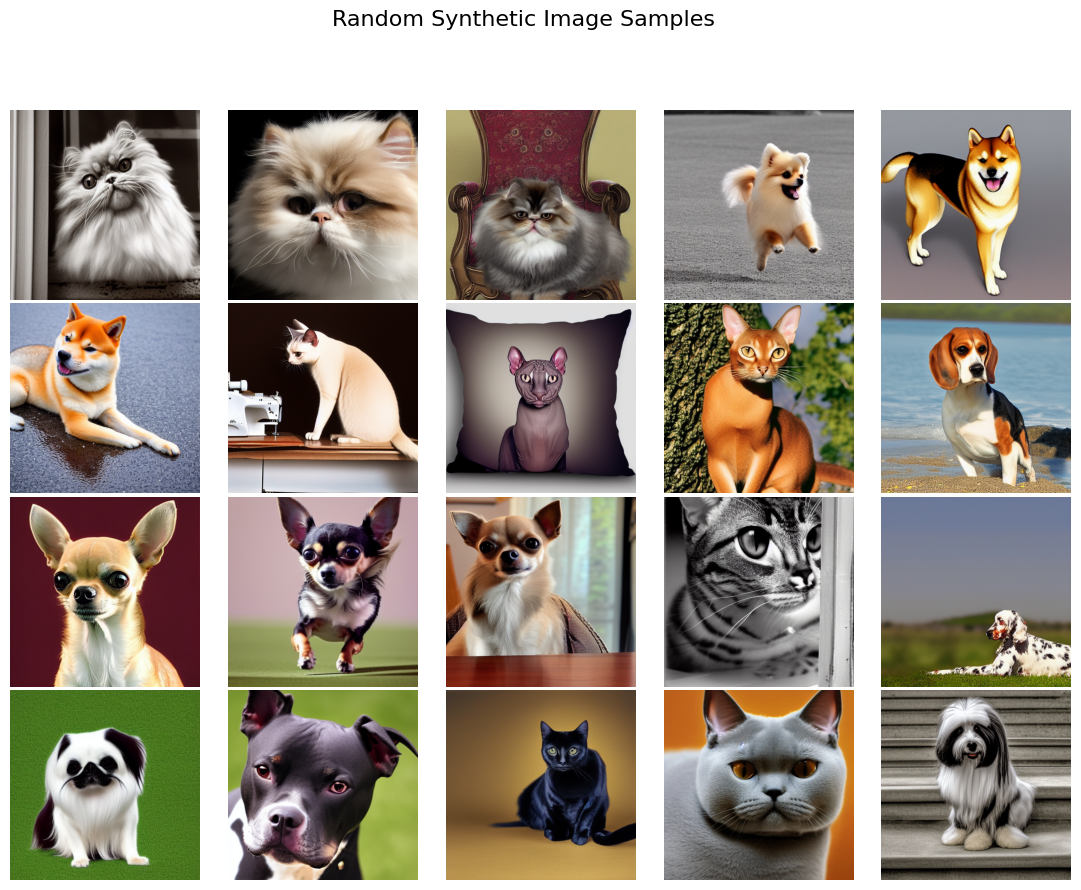

In [50]:
# display generated images
import os
import math
import matplotlib.pyplot as plt
from PIL import Image

# display images from showcase folder
SHOWCASE_DIR = os.path.join(DATA_DIR, "showcase_images")
image_files = sorted(os.listdir(SHOWCASE_DIR))

cols = 5
rows = 4

fig, axes = plt.subplots(rows, cols, figsize=(14, 10), dpi=100)

for ax, img_name in zip(axes.flatten(), image_files):
    img_path = os.path.join(SHOWCASE_DIR, img_name)
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.suptitle("Random Synthetic Image Samples", fontsize=16)
plt.subplots_adjust(wspace=0.02, hspace=0.02)
plt.show()

# Training and Evaluation

In this final stage, we evaluate whether synthetic data augmentation
improves classification performance.

Three training configurations are compared:

1. **Baseline**  
   - Real images only  
   - No data augmentation  
<br>

2. **Classical Augmentation**  
   - Real images  
   - Standard image transformations (flip, rotation, color jitter)
<br>
<br>

3. **Synthetic + Classical Augmentation**  
   - Real images with classical augmentation  
   - Additional synthetic images generated from selected captions  

Model:
- ResNet-18 pretrained on ImageNet

Evaluation:
- Accuracy on held-out test set
- Full classification report

This comparison quantifies the impact of generative data augmentation.

In [51]:
# Import training and evaluation module (final classification stage)
# This module:
# - Builds datasets
# - Trains models
# - Evaluates performance
# - Saves results and model weights

# ============================================
# Training & Evaluation Module (Integrated)
# ============================================

# src/training_evaluation.py

import os
import json
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from torch.utils.data import DataLoader, Subset, ConcatDataset
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


# Synthetic Dataset Wrapper
# This dataset loads synthetic images generated by Stable Diffusion model using metadata stored during generation.

class SyntheticDataset(torch.utils.data.Dataset):
    def __init__(self, metadata, class_to_idx, transform=None):

        """
        Args:
            metadata (dict): JSON metadata of generated images
            class_to_idx (dict): Mapping class name → numeric label
            transform: Image transformations
        """
        self.samples = []
        self.transform = transform
        self.class_to_idx = class_to_idx

        # Build (image_path, label) pairs
        for idx in metadata:
            for item in metadata[idx]:
                path = item["image_path"]
                class_name = item["class_name"]

                if class_name in class_to_idx:
                    label = class_to_idx[class_name]
                    self.samples.append((path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


# Model definition

# use pretrained Resnet18 (ImageNet weights). final fully connected layer adapated to dataset classes

def create_model(num_classes, device):
    model = models.resnet18(weights="IMAGENET1K_V1")
    model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


# Training Loop

# Standard supervised training loop:
#- CrossEntropyLoss
#- Adam optimizer

def train_model(model, train_loader, device, epochs=5):

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    model.train()

    for epoch in range(epochs):
        running_loss = 0

        for images, labels in tqdm(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

    return model


# Evaluation function to compute accuracy and full classification report

def evaluate_model(model, loader, device):

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    report_dict = classification_report(all_labels, all_preds, output_dict=True)
    cm = confusion_matrix(all_labels, all_preds)

    return accuracy, report_dict, cm

# Main Training Pipeline
# compares 3 training setups: baseline, classical augmentation only, and synthetic+classical augmentation

def run_training(PROJECT_ROOT, epochs=5, batch_size=64):

    # reproducibility
    import random

    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Transforms

    transform_train_no_aug = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])


    transform_train_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
        )
    ])


    transform_test = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])


    # Load real datasets

    dataset_train_no_aug = torchvision.datasets.OxfordIIITPet(
        root=os.path.join(PROJECT_ROOT, "data", "raw"),
        split="trainval",
        transform=transform_train_no_aug,
        download=True
    )

    dataset_train_aug = torchvision.datasets.OxfordIIITPet(
    root=os.path.join(PROJECT_ROOT, "data", "raw"),
    split="trainval",
    transform=transform_train_aug,
    download=True
    )

    dataset_test = torchvision.datasets.OxfordIIITPet(
        root=os.path.join(PROJECT_ROOT, "data", "raw"),
        split="test",
        transform=transform_test,
        download=True
    )

    train_small_idx = np.load(
        os.path.join(PROJECT_ROOT, "data", "splits", "train_small_indices.npy")
    )

    dataset_train_small_no_aug = Subset(dataset_train_no_aug, train_small_idx)
    dataset_train_small_aug = Subset(dataset_train_aug, train_small_idx)


    # load Synthetic dataset generated from stable diffusion

    metadata_path = os.path.join(
        PROJECT_ROOT,
        "data",
        "synthetic",
        "generation_metadata_final.json"
    )

    with open(metadata_path, "r") as f:
        generation_metadata = json.load(f)

    synthetic_dataset = SyntheticDataset(
        generation_metadata,
        dataset_train_aug.class_to_idx,
        transform=transform_train_aug
    )

    # Define 3 training configurations: Baseline, Classical augmentation, Synthetic + Classical Augmentation

    train_baseline = dataset_train_small_no_aug

    train_classical = dataset_train_small_aug

    train_synthetic_plus_classical = ConcatDataset([
        dataset_train_small_aug,
        synthetic_dataset
    ])


    # Loaders
    train_loader_baseline = DataLoader(
        train_baseline,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4
    )

    train_loader_classical = DataLoader(
        train_classical,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4
    )

    train_loader_synth_classical = DataLoader(
        train_synthetic_plus_classical,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4
    )

    test_loader = DataLoader(
        dataset_test,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4
    )

    # 1. Train baseline
    num_classes = len(dataset_train_no_aug.classes)


    print("\n===== Training Baseline =====")
    model_baseline = create_model(num_classes, device)
    model_baseline = train_model(model_baseline, train_loader_baseline, device, epochs)

    acc_baseline, report_baseline, cm_baseline = evaluate_model(model_baseline, test_loader, device)


    # 2. Train classical Augmentation
    print("\n===== Training Classical Augmentation =====")
    model_classical = create_model(num_classes, device)
    model_classical = train_model(model_classical, train_loader_classical, device, epochs)

    acc_classical, report_classical, cm_classical = evaluate_model(model_classical, test_loader, device)


    # 3. Train Synthetic + Classical Augmentation
    print("\n===== Training Synthetic + Classical =====")
    model_synth_classical = create_model(num_classes, device)
    model_synth_classical = train_model(model_synth_classical, train_loader_synth_classical, device, epochs)

    acc_synth_classical, report_synth_classical, cm_synth_classical = evaluate_model(model_synth_classical, test_loader, device)


    # save results and models
    MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
    os.makedirs(MODEL_DIR, exist_ok=True)

    # save Metrics and model weights

    # Store:
    # - Accuracy
    # - Classification reports
    # - Experiment metadata
    # - Model weights

    class_names = dataset_train_no_aug.classes
    results = {
        "class_names": class_names,
        "baseline": {
            "accuracy": acc_baseline,
            "report": report_baseline,
            "confusion_matrix": cm_baseline.tolist()
        },
        "classical_only": {
            "accuracy": acc_classical,
            "report": report_classical,
            "confusion_matrix": cm_classical.tolist()
        },
        "synthetic_plus_classical": {
            "accuracy": acc_synth_classical,
            "report": report_synth_classical,
            "confusion_matrix": cm_synth_classical.tolist()
        },
        "experiment_info": {
            "train_size_real_small": len(dataset_train_small_no_aug),
            "train_size_classical": len(dataset_train_small_aug),
            "train_size_synthetic_only": len(synthetic_dataset),
            "train_size_synthetic_plus_classical": len(train_synthetic_plus_classical),
            "test_size": len(dataset_test),
            "epochs": epochs,
            "batch_size": batch_size,
            "model": "ResNet18",
            "random_seed": 42
        }
    }

    with open(os.path.join(MODEL_DIR, "evaluation_results.json"), "w") as f:
        json.dump(results, f, indent=4)

    # save model weights
    torch.save(
        model_baseline.state_dict(),
        os.path.join(MODEL_DIR, "resnet18_baseline.pth")
    )

    torch.save(
    model_classical.state_dict(),
    os.path.join(MODEL_DIR, "resnet18_classical.pth")
    )

    torch.save(
        model_synth_classical.state_dict(),
        os.path.join(MODEL_DIR, "resnet18_synth_classical.pth")
    )

    return results


In [52]:
#execute Training Pipeline
# Estimated runtime: ~1 minute on A100 GPU in colab
if RUN_TRAINING:

    results = run_training(
        PROJECT_ROOT,
        epochs=5,
        batch_size=64
    )


===== Training Baseline =====
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]
100%|██████████| 18/18 [00:03<00:00,  5.26it/s]


Epoch 1/5, Loss: 3.0997


100%|██████████| 18/18 [00:02<00:00,  7.48it/s]


Epoch 2/5, Loss: 1.4395


...

Epoch 3/5, Loss: 0.3236


100%|██████████| 52/52 [00:14<00:00,  3.61it/s]


Epoch 4/5, Loss: 0.2022


100%|██████████| 52/52 [00:14<00:00,  3.60it/s]

Epoch 5/5, Loss: 0.1368


# Results

In [53]:
#print final accuracy comparison
print("Baseline Accuracy:", round(results["baseline"]["accuracy"],4))
print("Classical Augmentation Accuracy:", round(results["classical_only"]["accuracy"],4))
print("Synthetic + Classical Augmentation Accuracy:", round(results["synthetic_plus_classical"]["accuracy"],4))

Baseline Accuracy: 0.825
Classical Augmentation Accuracy: 0.8277
Synthetic + Classical Augmentation Accuracy: 0.8354


## Performance Comparison

In [55]:
# Build RESULTS comparison table

import os
import json
import pandas as pd
from tabulate import tabulate

MODEL_DIR = os.path.join(PROJECT_ROOT, "models")

with open(os.path.join(MODEL_DIR, "evaluation_results.json"), "r") as f:
    results = json.load(f)

table_data = []

for setup_name in ["baseline", "classical_only", "synthetic_plus_classical"]:

    acc = results[setup_name]["accuracy"]
    report = results[setup_name]["report"]

    macro_f1 = report["macro avg"]["f1-score"]
    weighted_f1 = report["weighted avg"]["f1-score"]
    precision = report["macro avg"]["precision"]
    recall = report["macro avg"]["recall"]

    table_data.append({
        "Training Strategy": setup_name,
        "Accuracy": round(acc, 4),
        "Macro F1": round(macro_f1, 4),
        "Weighted F1": round(weighted_f1, 4),
        "Macro Precision": round(precision, 4),
        "Macro Recall": round(recall, 4)
    })

results_table = pd.DataFrame(table_data)

#save table to CSV
results_table.to_csv(
    os.path.join(PROJECT_ROOT, "models", "evaluation_summary_table.csv"),
    index=False
)

# print table
print("\n==============================")
print(" Final Evaluation Comparison ")
print("==============================")

print(tabulate(
    results_table,
    headers="keys",
    tablefmt="rounded_grid",
    showindex=False,
    floatfmt=".4f"
))


 Final Evaluation Comparison 
╭──────────────────────────┬────────────┬────────────┬───────────────┬───────────────────┬────────────────╮
│ Training Strategy        │   Accuracy │   Macro F1 │   Weighted F1 │   Macro Precision │   Macro Recall │
├──────────────────────────┼────────────┼────────────┼───────────────┼───────────────────┼────────────────┤
│ baseline                 │     0.8250 │     0.8228 │        0.8234 │            0.8275 │         0.8245 │
├──────────────────────────┼────────────┼────────────┼───────────────┼───────────────────┼────────────────┤
│ classical_only           │     0.8277 │     0.8242 │        0.8247 │            0.8335 │         0.8273 │
├──────────────────────────┼────────────┼────────────┼───────────────┼───────────────────┼────────────────┤
│ synthetic_plus_classical │     0.8354 │     0.8342 │        0.8349 │            0.8464 │         0.8345 │
╰──────────────────────────┴────────────┴────────────┴───────────────┴───────────────────┴───────────────

## Class-Level Performance Comparison (F1-Score)

In [56]:

# CLASS LEVEL COMPARISON - F1 SCORE

class_names = results["class_names"]

class_level_rows = []

for class_name in class_names:

    row = {"Class": class_name}
    label_index = str(class_names.index(class_name))

    for setup in ["baseline", "classical_only", "synthetic_plus_classical"]:
        row[setup + "_F1"] = round(
            results[setup]["report"][label_index]["f1-score"], 4
        )

    class_level_rows.append(row)

class_level_df = pd.DataFrame(class_level_rows)

print("\n==============================")
print(" Per-Class F1 Comparison ")
print("==============================")


print(tabulate(
    class_level_df,
    headers="keys",
    tablefmt="rounded_grid",
    showindex=False,
    floatfmt=".4f"
))


# Save tabl to CSV
class_level_df.to_csv(
    os.path.join(PROJECT_ROOT, "models", "per_class_f1_comparison.csv"),
    index=False
)


 Per-Class F1 Comparison 
╭────────────────────────────┬───────────────┬─────────────────────┬───────────────────────────────╮
│ Class                      │   baseline_F1 │   classical_only_F1 │   synthetic_plus_classical_F1 │
├────────────────────────────┼───────────────┼─────────────────────┼───────────────────────────────┤
│ Abyssinian                 │        0.7283 │              0.7322 │                        0.7708 │
├────────────────────────────┼───────────────┼─────────────────────┼───────────────────────────────┤
│ American Bulldog           │        0.7542 │              0.7154 │                        0.6966 │
├────────────────────────────┼───────────────┼─────────────────────┼───────────────────────────────┤
│ American Pit Bull Terrier  │        0.5529 │              0.4690 │                        0.5909 │
├────────────────────────────┼───────────────┼─────────────────────┼───────────────────────────────┤
│ Basset Hound               │        0.7723 │              0.80

## Confusion Matrix

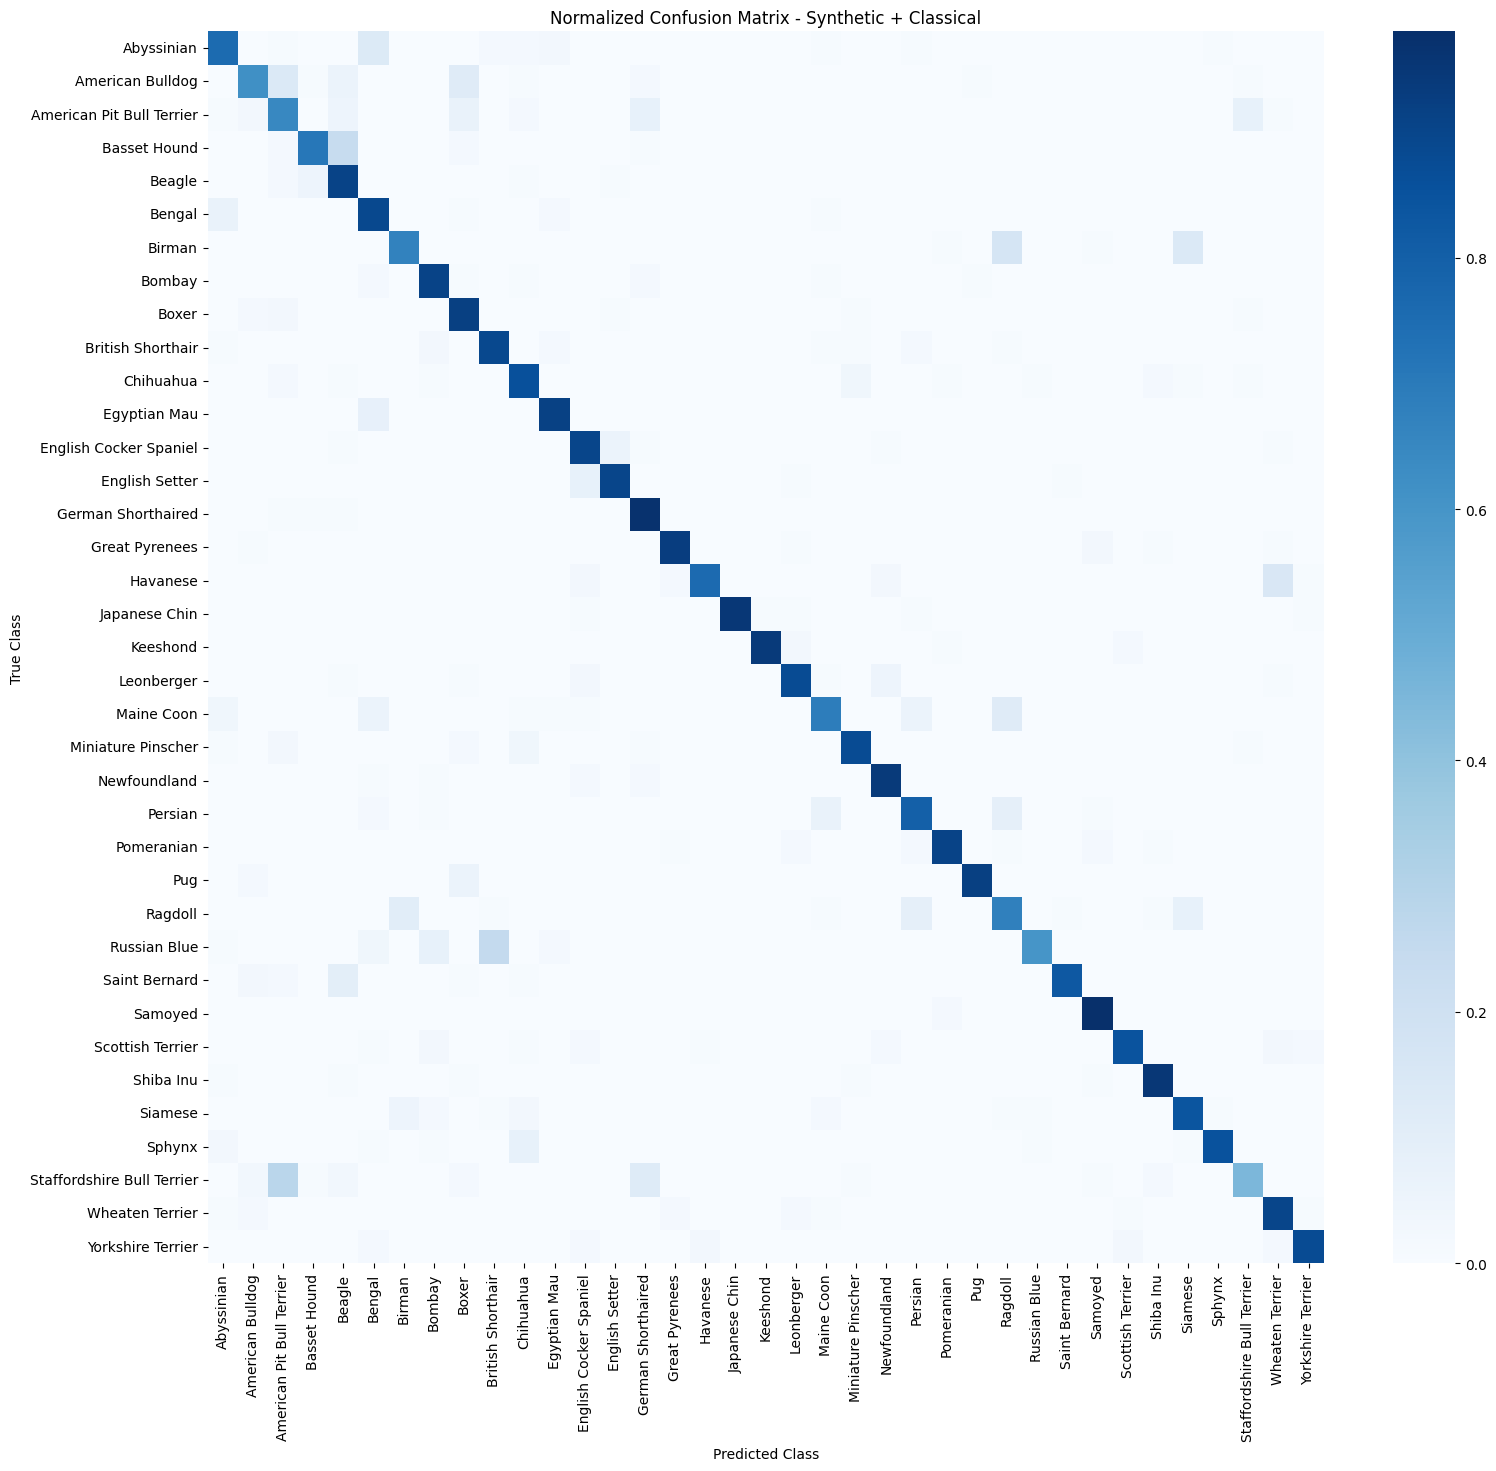

In [57]:
import seaborn as sns

class_names = results["class_names"]

cm = np.array(results["synthetic_plus_classical"]["confusion_matrix"])
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(18, 16))

sns.heatmap(
    cm_normalized,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.title("Normalized Confusion Matrix - Synthetic + Classical")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

In [58]:
# Create output dir

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "models/confusion_matrix_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

#Save PNG
png_path = os.path.join(OUTPUT_DIR, "confusion_matrix_normalized.png")
plt.figure(figsize=(18, 16))
plt.imshow(cm_normalized)
plt.colorbar()
plt.title("Normalized Confusion Matrix - Synthetic + Classical")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.savefig(png_path, bbox_inches="tight", dpi=300)
plt.close()

#Save CSV
csv_path = os.path.join(OUTPUT_DIR, "confusion_matrix_normalized.csv")
pd.DataFrame(cm_normalized, index=class_names, columns=class_names).to_csv(csv_path)

print("Saved files:")
print(png_path)
print(csv_path)

Saved files:
/content/Project_Generative_AI_for_Data_Augmentation/models/confusion_matrix_outputs/confusion_matrix_normalized.png
/content/Project_Generative_AI_for_Data_Augmentation/models/confusion_matrix_outputs/confusion_matrix_normalized.csv


# Conclusion

## **Project Overview**

This project evaluated whether text-driven synthetic data augmentation improves fine-grained image classification on the Oxford-IIIT Pet dataset (37 classes).

Three configurations were compared under identical conditions:

- Baseline – real images only

- Classical augmentation – standard transformations (flip, rotation, color jitter)

- Synthetic + classical augmentation – Stable Diffusion–generated images from filtered caption variations

## **Results**

**Accuracy**

- Baseline: 0.8250

- Classical augmentation: 0.8277

- Synthetic + classical: 0.8354

Key insights:

- Classical augmentation yielded only a marginal improvement over the baseline

- Synthetic + classical augmentation achieved +1.04 percentage points over baseline.

- This is a substantial gain for a 37-class fine-grained problem.

<br>

**Macro F1-Score**

Macro F1-score provides a more robust evaluation metric because it equally weights all classes, regardless of frequency.

- Baseline: 0.8228

- Classical augmentation: 0.8242

- Synthetic + classical: 0.8342

Key insights:

- ~+1.14 point improvement with synthetic data.

- Gains are distributed across classes, not concentrated in dominant ones.

- Weighted F1-score follows the same trend.

A visual inspection of the confusion matrix shows that the most frequent misclassifications occur between visually similar breeds:

- Ragdoll ↔ Birman

- Staffordshire Bull Terrier ↔ American Pit Bull Terrier

- Russian Blue  ↔ British Shorthair

- Basset Hound  ↔ Beagle

<br>

**Class-Level Behaviour**

The synthetic + classical configuration improved several mid-performing and visually ambiguous breeds, including:

Abyssinian (0.73 → 0.77)

Bengal (0.68 → 0.78)

Chihuahua (0.69 → 0.82)

British Shorthair (0.74 → 0.82)

Shiba Inu (0.88 → 0.94)

Some visually similar breed (e.g., American Pit Bull Terrier, Staffordshire Bull Terrier) remain challenging. These classes maintain lower F1-scores relative to the dataset average, even under synthetic augmentation.

<br>

## **Why the Improvement matters**

Although the synthetic + classical training configuration approx. tripled the dataset size (from 1104 to 3274 images), the performance gain is not just due to quantity. If the generated images were were noisy or unrealistic, performance would likely degrade.
Instead, the observed improvement suggests that the synthetic data adds:

- Structured semantic diversity

- New poses and compositions

- Varied backgrounds

This enhances feature learning and generalization.

<br>

## **Pipeline**

- caption generation (BLIP2)
- caption variation (instruction-tuned LLM – Mistral, selected after comparative evaluation)
- semantic filtering
- image synthesis (Stable Diffusion v1.5)
- training with pretrained ResNet-18 backbone

The experimental design controlled for model architecture, hyperparameters, dataset split, and random seed to isolate the effect of augmentation strategy.

Overall, the results demonstrate that a structured generative augmentation pipeline can produce meaningful improvements in classification performance in data-limited scenarios.


# Further Improvements

Future work could explore:

- larger synthetic-to-real data ratios
- different diffusion models
- execute full pipeline on the complete training set (thi study was conducted using 30% of the available training data due to computational constraints in Colab)

In [59]:
# # capture exact libraries version used in current environemnt in colab
# !pip freeze | grep -E "torch|torchvision|sentence-transformers|transformers|diffusers|accelerate|sentencepiece|scikit-learn|xformers|matplotlib|numpy|pillow|tqdm|bitsandbytes" > requirements_locked.txt

-----------

<p align="center">
  <img src="https://github.com/Jorj91/Project_Generative_AI_for_Data_Augmentation/blob/dev/assets/synth_images_genai_project.png?raw=1" width="700"/>
</p>

In [60]:
# import json

# NOTEBOOK_PATH = "/content/Project_Generative_AI_for_Data_Augmentation/main.ipynb"

# with open(NOTEBOOK_PATH, "r", encoding="utf-8") as f:
#     nb = json.load(f)

# # Remove ANY widget metadata anywhere in the notebook
# for cell in nb.get("cells", []):
#     # Remove cell-level widgets metadata
#     if "metadata" in cell and "widgets" in cell["metadata"]:
#         del cell["metadata"]["widgets"]

#     # Remove widget metadata inside outputs
#     for output in cell.get("outputs", []):
#         if "metadata" in output and "widgets" in output["metadata"]:
#             del output["metadata"]["widgets"]

# # Also remove top-level widget blocks if any hidden keys exist
# if "metadata" in nb:
#     for key in list(nb["metadata"].keys()):
#         if "widget" in key.lower():
#             del nb["metadata"][key]

# with open(NOTEBOOK_PATH, "w", encoding="utf-8") as f:
#     json.dump(nb, f, indent=1)

# print("All widget metadata removed everywhere.")

In [61]:
# import nbformat

# INPUT_PATH = "main.ipynb"
# OUTPUT_PATH = "main_rebuilt.ipynb"

# nb = nbformat.read(INPUT_PATH, as_version=4)

# new_nb = nbformat.v4.new_notebook()
# new_nb.metadata = nb.metadata  # keep clean metadata

# for cell in nb.cells:
#     # Preserve cell type (code or markdown)
#     if cell.cell_type == "code":
#         new_cell = nbformat.v4.new_code_cell(cell.source)
#     else:
#         new_cell = nbformat.v4.new_markdown_cell(cell.source)

#     # Preserve execution count
#     new_cell.execution_count = cell.get("execution_count", None)

#     # Clean outputs
#     cleaned_outputs = []
#     for output in cell.get("outputs", []):
#         if "data" in output:
#             output["data"] = {
#                 k: v for k, v in output["data"].items()
#                 if "widget" not in k.lower()
#             }
#         if "metadata" in output:
#             output["metadata"] = {
#                 k: v for k, v in output["metadata"].items()
#                 if "widget" not in k.lower()
#             }
#         cleaned_outputs.append(output)

#     new_cell.outputs = cleaned_outputs
#     new_nb.cells.append(new_cell)

# nbformat.write(new_nb, OUTPUT_PATH)

# print("Notebook successfully rebuilt as main_rebuilt.ipynb")